# DETR3D End-to-End Walkthrough

This notebook is meant to be read top to bottom. It starts from raw nuScenes files on disk, constructs a DETR3D-ready PyTorch batch, then defines each architecture component from scratch one by one.

## Notebook Roadmap

1. Raw nuScenes data layout
2. Metadata table loading from scratch
3. Sample linkage across cameras
4. Calibration and projection matrices
5. Ground-truth target construction
6. Image preprocessing and collate
7. Backbone
8. FPN
9. Reference points and feature sampling
10. Cross-attention
11. Decoder layer and transformer
12. Detection head and full model
13. Matcher and loss
14. Training step and experiments

In [1]:
from __future__ import annotations

import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# Make package imports work whether the notebook is launched from the repo root or from notebooks/.
_CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (_CWD, _CWD.parent) if (candidate / 'detr3d').is_dir() and (candidate / 'train.py').exists()),
    _CWD,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"torch.is_cuda_available: {torch.cuda.is_available()}")

torch.is_cuda_available: True


## 1. Raw nuScenes Data Layout

The extracted dataset root should look like this:

```text
nuscenes/
├── maps/
├── samples/
│   ├── CAM_FRONT/
│   ├── CAM_FRONT_LEFT/
│   ├── CAM_FRONT_RIGHT/
│   ├── CAM_BACK/
│   ├── CAM_BACK_LEFT/
│   └── CAM_BACK_RIGHT/
├── sweeps/
├── v1.0-trainval/
│   ├── sample.json
│   ├── sample_data.json
│   ├── sample_annotation.json
│   ├── calibrated_sensor.json
│   ├── ego_pose.json
│   ├── sensor.json
│   ├── category.json
│   └── ...
└── v1.0-test/
```

The core idea is: images live in `samples/` or `sweeps/`, but the training labels, camera calibration, and ego poses live in the JSON tables under `v1.0-trainval/`.

In [2]:
DATAROOT = Path('/home/user/datasets/nuscenes')
VERSION = 'v1.0-trainval'
META_ROOT = DATAROOT / VERSION

print(DATAROOT)
print(META_ROOT)
print((DATAROOT / 'samples').exists(), (META_ROOT / 'sample.json').exists())

/home/user/datasets/nuscenes
/home/user/datasets/nuscenes/v1.0-trainval
True True


## 2. Metadata Table Loading From Scratch

Instead of relying on the nuScenes SDK first, we make the structure explicit. The objective is to understand how a raw `sample` row links to camera frames, annotations, calibrations, and poses through the other JSON tables.

In [3]:
def load_table(meta_root: Path, name: str):
    path = meta_root / f'{name}.json'
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def build_index(rows: List[dict], key: str = 'token') -> Dict[str, dict]:
    return {row[key]: row for row in rows}


def build_group_index(rows: List[dict], key: str) -> Dict[str, List[dict]]:
    grouped = {}
    for row in rows:
        grouped.setdefault(row[key], []).append(row)
    return grouped


sample_table = load_table(META_ROOT, 'sample')
sample_data_table = load_table(META_ROOT, 'sample_data')
sample_annotation_table = load_table(META_ROOT, 'sample_annotation')
calibrated_sensor_table = load_table(META_ROOT, 'calibrated_sensor')
ego_pose_table = load_table(META_ROOT, 'ego_pose')
sensor_table = load_table(META_ROOT, 'sensor')
category_table = load_table(META_ROOT, 'category')
instance_table = load_table(META_ROOT, 'instance')

sample_by_token = build_index(sample_table)
sample_data_by_token = build_index(sample_data_table)
sample_data_by_sample_token = build_group_index(sample_data_table, 'sample_token')
annotation_by_token = build_index(sample_annotation_table)
sample_annotations_by_sample_token = build_group_index(sample_annotation_table, 'sample_token')
calibrated_sensor_by_token = build_index(calibrated_sensor_table)
ego_pose_by_token = build_index(ego_pose_table)
sensor_by_token = build_index(sensor_table)
category_by_token = build_index(category_table)
instance_by_token = build_index(instance_table)

sample_count = len(sample_table)
sample_data_count = len(sample_data_table)
sample_annotation_count = len(sample_annotation_table)

print(f"sample_table has {sample_count} rows. This means there are {sample_count} samples(frames) in the metadata.")
print(f"sample_data_table has {sample_data_count} rows. This means there are {sample_data_count} sensor records, like camera or lidar captures.")
print(f"sample_annotation_table has {sample_annotation_count} rows. This means there are {sample_annotation_count} labeled 3D object annotations.")

sample_table has 34149 rows. This means there are 34149 samples(frames) in the metadata.
sample_data_table has 2631083 rows. This means there are 2631083 sensor records, like camera or lidar captures.
sample_annotation_table has 1166187 rows. This means there are 1166187 labeled 3D object annotations.


## 3. Linking One Sample to Its 6 Cameras

In the raw JSON tables, a nuScenes `sample` does not directly contain a `data` dictionary. We rebuild the six camera records by following `sample -> sample_data -> calibrated_sensor -> sensor`.
- `CAM_FRONT`
- `CAM_FRONT_LEFT`
- `CAM_FRONT_RIGHT`
- `CAM_BACK`
- `CAM_BACK_LEFT`
- `CAM_BACK_RIGHT`

In [4]:
CAMERA_NAMES = [
    'CAM_FRONT',
    'CAM_FRONT_LEFT',
    'CAM_FRONT_RIGHT',
    'CAM_BACK',
    'CAM_BACK_LEFT',
    'CAM_BACK_RIGHT',
]


def get_camera_records(
    sample_record: dict,
    sample_data_by_sample_token: Dict[str, List[dict]],
    calibrated_sensor_by_token: Dict[str, dict],
    sensor_by_token: Dict[str, dict],
):
    camera_records = {}
    sample_data_records = sample_data_by_sample_token.get(sample_record['token'], [])
    for record in sample_data_records:
        calibrated_sensor = calibrated_sensor_by_token[record['calibrated_sensor_token']]
        sensor = sensor_by_token[calibrated_sensor['sensor_token']]
        camera_name = sensor['channel']
        if sensor['modality'] == 'camera' and camera_name in CAMERA_NAMES:
            camera_records[camera_name] = record

    missing = [camera_name for camera_name in CAMERA_NAMES if camera_name not in camera_records]
    if missing:
        raise KeyError(f'Missing camera records for sample {sample_record["token"]}: {missing}')

    return {camera_name: camera_records[camera_name] for camera_name in CAMERA_NAMES}


sample_record = sample_table[0]
camera_records = get_camera_records(
    sample_record,
    sample_data_by_sample_token,
    calibrated_sensor_by_token,
    sensor_by_token,
)
{name: record['filename'] for name, record in camera_records.items()}

{'CAM_FRONT': 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883530412470.jpg',
 'CAM_FRONT_LEFT': 'samples/CAM_FRONT_LEFT/n015-2018-07-18-11-07-57+0800__CAM_FRONT_LEFT__1531883530404844.jpg',
 'CAM_FRONT_RIGHT': 'samples/CAM_FRONT_RIGHT/n015-2018-07-18-11-07-57+0800__CAM_FRONT_RIGHT__1531883530420339.jpg',
 'CAM_BACK': 'samples/CAM_BACK/n015-2018-07-18-11-07-57+0800__CAM_BACK__1531883530437525.jpg',
 'CAM_BACK_LEFT': 'samples/CAM_BACK_LEFT/n015-2018-07-18-11-07-57+0800__CAM_BACK_LEFT__1531883530447423.jpg',
 'CAM_BACK_RIGHT': 'samples/CAM_BACK_RIGHT/n015-2018-07-18-11-07-57+0800__CAM_BACK_RIGHT__1531883530427893.jpg'}

## 4. Calibration and Projection Matrices

DETR3D projects a 3D reference point into each camera image, then samples image features at the projected location. So the data pipeline must build per-camera projection matrices.

We will use `lidar2img` as the conventional key name in `img_metas`, even though the actual transform we build here is `ego -> image`. Many DETR3D codebases keep the `lidar2img` key name even when the common 3D frame is ego-centric.

In [5]:
def quaternion_to_rotation_matrix(q):
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)],
        [2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
        [2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)],
    ], dtype=np.float32)


def pose_to_matrix(rotation, translation):
    matrix = np.eye(4, dtype=np.float32)
    matrix[:3, :3] = quaternion_to_rotation_matrix(rotation)
    matrix[:3, 3] = np.asarray(translation, dtype=np.float32)
    return matrix


def invert_se3(matrix):
    rotation = matrix[:3, :3]
    translation = matrix[:3, 3]
    inv = np.eye(4, dtype=np.float32)
    inv[:3, :3] = rotation.T
    inv[:3, 3] = -rotation.T @ translation
    return inv


def build_lidar2img(camera_record):
    calibrated_sensor = calibrated_sensor_by_token[camera_record['calibrated_sensor_token']]

    cam_to_ego = pose_to_matrix(calibrated_sensor['rotation'], calibrated_sensor['translation'])
    ego_to_cam = invert_se3(cam_to_ego)

    intrinsic = np.eye(4, dtype=np.float32)
    intrinsic[:3, :3] = np.asarray(calibrated_sensor['camera_intrinsic'], dtype=np.float32)
    return intrinsic @ ego_to_cam


lidar2img = np.stack([build_lidar2img(record) for record in camera_records.values()], axis=0)
lidar2img.shape

(6, 4, 4)

## 5. Building 3D Targets From Raw Annotations

A DETR3D training target needs 3D boxes and class ids in one consistent frame. Raw nuScenes annotations are stored in the global frame, so the package dataset converts each box into the LiDAR frame, then represents it with the package's 9D semantic box contract: `[x, y, z, w, l, h, yaw, vx, vy]`.


In [6]:
from detr3d.data.nuscenes_dataset import CLASS_TO_ID, NUSCENES_CLASSES

# The package dataset now owns class mapping, lidar-frame GT conversion, and lidar2img geometry.
NUSCENES_CLASSES, CLASS_TO_ID


(['car',
  'truck',
  'bus',
  'trailer',
  'construction_vehicle',
  'pedestrian',
  'motorcycle',
  'bicycle',
  'traffic_cone',
  'barrier'],
 {'car': 0,
  'truck': 1,
  'bus': 2,
  'trailer': 3,
  'construction_vehicle': 4,
  'pedestrian': 5,
  'motorcycle': 6,
  'bicycle': 7,
  'traffic_cone': 8,
  'barrier': 9})

## 6. Image Preprocessing And PyTorch Dataset Contract

The job here is to turn raw JPEGs plus metadata into tensors that the model can consume directly. The end result per sample should look like:

```python
{
    'images': Tensor[N, 3, H, W],
    'img_metas': {
        'lidar2img': Tensor[N, 4, 4],
        'image_shape': Tensor[N, 2],
        'sample_token': str,
    },
    'gt_boxes_lidar': Tensor[M, 9],
    'gt_labels': Tensor[M],
}
```

Shape meanings:
- `N` = number of cameras, so `N=6` for nuScenes.
- `H, W` = resized image height and width used by the model, not the raw JPEG resolution.
- `M` = number of objects in this sample. This stays variable because every scene has a different number of boxes.
- `gt_boxes_lidar` now uses the package's 9D semantic box contract: `[x, y, z, w, l, h, yaw, vx, vy]`.

The asymmetry here is intentional: images are dense and easy to stack into one tensor, while targets are sparse and variable-length, so they stay as per-sample lists until loss computation.


In [7]:
# Minimal shape-only example before we touch the real dataset.
import torch

# The notebook uses a reduced resolution for walkthrough/runtime practicality.
B, N, H, W = 2, 6, 832, 1472

images = torch.randn(B, N, 3, H, W)
img_metas = [
    {
        'lidar2img': torch.eye(4).unsqueeze(0).repeat(N, 1, 1),
        'image_shape': torch.tensor([[H, W]]).repeat(N, 1),
    }
    for _ in range(B)
]

gt_boxes_lidar = [torch.randn(8, 9), torch.randn(5, 9)]
gt_labels = [torch.randint(0, 10, (8,)), torch.randint(0, 10, (5,))]

images.shape, len(img_metas), gt_boxes_lidar[0].shape, gt_labels[0].shape


(torch.Size([2, 6, 3, 832, 1472]), 2, torch.Size([8, 9]), torch.Size([8]))

In [8]:
from detr3d.data import NuScenesDetr3DDataset

# For notebook execution we keep the package dataset but use a reduced image size.
dataset = NuScenesDetr3DDataset(DATAROOT, version='v1.0-trainval', image_size=(832, 1472))
sample = dataset[0]
sample['images'].shape, sample['img_metas']['lidar2img'].shape, sample['gt_boxes_lidar'].shape


(torch.Size([6, 3, 832, 1472]), torch.Size([6, 4, 4]), torch.Size([10, 9]))

In [9]:
from detr3d.data import detr3d_collate

batch = detr3d_collate([dataset[0], dataset[1]])
batch['images'].shape, len(batch['img_metas']), len(batch['gt_boxes_lidar'])


(torch.Size([2, 6, 3, 832, 1472]), 2, 2)

From this point on, the model does not care about raw JSON or JPEG files anymore. It only sees the PyTorch batch contract we just built.

## 7. Backbone

The backbone extracts per-camera 2D image features. The only multi-view step here is flattening `[B, N, 3, H, W]` into `[B*N, 3, H, W]`, applying the CNN, then reshaping back to `[B, N, C, H_l, W_l]`.

Why flatten first? Because the CNN does not need to know which camera a feature came from. Each image can be processed independently with shared weights, and reshaping to `B*N` lets us reuse ordinary 2D conv layers without writing a special multi-camera backbone.

In [10]:
from detr3d.models.backbone import MultiViewImageBackbone

# Use the package backbone directly so the notebook stays aligned with the project code.
backbone = MultiViewImageBackbone(pretrained=True)
backbone_features = backbone(images[:2])
{name: feat.shape for name, feat in backbone_features.items()}


{'stage3': torch.Size([2, 6, 512, 104, 184]),
 'stage4': torch.Size([2, 6, 1024, 52, 92]),
 'stage5': torch.Size([2, 6, 2048, 26, 46])}

## 8. FPN

The neck merges multiple backbone stages into a semantic pyramid with aligned channel dimensions. DETR3D later samples from these levels when projecting 3D queries into the images.

Why do all pyramid levels end up with the same channel count? Because attention wants one common embedding size across levels. Spatial resolution can differ by level, but channel dimension should stay aligned so the sampled features can be fused cleanly.

In [11]:
from detr3d.models.neck import ImageFPN

neck = ImageFPN()
pyramid = neck(backbone_features)
{name: feat.shape for name, feat in pyramid.items()}


{'p3': torch.Size([2, 6, 256, 104, 184]),
 'p4': torch.Size([2, 6, 256, 52, 92]),
 'p5': torch.Size([2, 6, 256, 26, 46]),
 'p6': torch.Size([2, 6, 256, 13, 23])}

## 9. Reference Points And Feature Sampling

DETR3D keeps the model image-only, but the geometry lives in the LiDAR coordinate frame. Learned 3D reference points are interpreted in that frame and projected into each camera with `lidar2img`.

In this notebook we now rely on the package implementation for the actual feature sampling path, so the notebook no longer carries a second copy of that logic. The important shapes are still:
- `reference_points`: `[B, Q, 3]` normalized 3D query anchors
- `lidar2img`: `[B, N, 4, 4]` projection matrices from LiDAR frame to each camera image
- sampled features inside cross-attention: `[B, C, Q, N, 1, L]`


In [12]:
from detr3d.models.transformer.feature_sampling import feature_sampling
from detr3d.models.transformer.reference_points import denormalize_reference_points, inverse_sigmoid

ref_points = torch.rand(2, 100, 3)
ref_points_3d, sampled_feats, sampled_mask = feature_sampling(
    list(pyramid.values()),
    ref_points,
    (-51.2, -51.2, -5.0, 51.2, 51.2, 3.0),
    batch['img_metas'][:2],
)
{
    'reference_points_3d': ref_points_3d.shape,
    'sampled_feats': sampled_feats.shape,
    'sampled_mask': sampled_mask.shape,
}


{'reference_points_3d': torch.Size([2, 100, 3]),
 'sampled_feats': torch.Size([2, 256, 100, 6, 1, 4]),
 'sampled_mask': torch.Size([2, 1, 100, 6, 1, 4])}

## 10. Cross-Attention

The package cross-attention is now the source of truth. It predicts camera/level weights from each query, projects LiDAR-frame reference points into the image pyramid, and fuses sampled image features back into the query state.

The important modeling point is still the same: DETR3D does not attend over every image pixel densely. It samples image features at projected 3D query locations.


In [13]:
from detr3d.models.transformer.cross_attention import Detr3DCrossAttention

embed_dims = 256
num_queries = 100
cross_attn = Detr3DCrossAttention(num_levels=4)
query = torch.randn(2, num_queries, embed_dims)
query_pos = torch.randn(2, num_queries, embed_dims)
reference_points = torch.rand(2, num_queries, 3)
fused = cross_attn(
    query=query,
    mlvl_feats=list(pyramid.values()),
    reference_points=reference_points,
    img_metas=batch['img_metas'][:2],
    query_pos=query_pos,
)
fused.shape


torch.Size([2, 100, 256])

## 11. Decoder Layer And Transformer

The decoder alternates self-attention among object queries and DETR3D cross-attention into the multi-view image features.

The notebook now imports the package transformer directly, so there is only one implementation to debug. The key shapes remain:
- query/state tensors: `[B, Q, C]`
- stacked decoder outputs: `[num_layers, B, Q, C]`
- reference points: `[B, Q, 3]`


In [14]:
from detr3d.models.transformer import Detr3DTransformer
from detr3d.models.heads import Detr3DHead

head = Detr3DHead(num_decoder_layers=6)
transformer = Detr3DTransformer(num_queries=100, num_levels=4)
hs, init_reference, inter_references = transformer(
    pyramid,
    img_metas=batch["img_metas"][:2],
    reference_point_predictor=head.predict_reference_points,
)
{
    "hs": hs.shape,
    "init_reference": init_reference.shape,
    "inter_references": inter_references.shape,
}


{'hs': torch.Size([6, 2, 100, 256]),
 'init_reference': torch.Size([2, 100, 3]),
 'inter_references': torch.Size([6, 2, 100, 3])}

## 12. Detection Head And Full Model

The head predicts classes and 3D boxes from each decoder layer. The full model is now just composition: backbone -> neck -> transformer -> head.

In [15]:
from detr3d.models import Detr3DModel
from detr3d.models.heads import Detr3DHead

cls_scores, bbox_preds = head(hs, inter_references)
model = Detr3DModel(
    backbone=MultiViewImageBackbone(pretrained=False),
    neck=ImageFPN(),
    transformer=Detr3DTransformer(num_queries=100, num_levels=4),
    head=Detr3DHead(num_decoder_layers=6),
)

{
    "cls_scores": cls_scores.shape,
    "bbox_preds": bbox_preds.shape,
    "head_box_dim": head.box_dim,
}


{'cls_scores': torch.Size([6, 2, 100, 10]),
 'bbox_preds': torch.Size([6, 2, 100, 10]),
 'head_box_dim': 10}

## 13. Matcher And Loss

This walkthrough now follows the package's restored official-style training path more closely.

What the paper text explicitly specifies:
- semantic `R^9` GT boxes: position, size, heading, velocity
- set-to-set Hungarian matching
- focal classification loss
- `L1` box supervision

What the paper text does **not** specify exactly:
- whether training should use raw 9D targets or an encoded target
- exact matcher weights for class cost vs box cost
- exact no-object / classification normalization details
- numerical safeguards used in code

What the package now does:
- keeps dataset GT boxes as semantic `9D`
- encodes them internally to the official-style `10D` target
- predicts encoded `10D` boxes from the head
- decodes predictions back to semantic `9D` for diagnostics and visualization
- uses official-style focal matcher weighting by default


In [16]:
from detr3d.models.losses import Detr3DLoss

criterion = Detr3DLoss(num_classes=10, use_auxiliary_losses=False, debug=True)
outputs = model(batch['images'][:2], batch['img_metas'][:2])
loss_dict = criterion.loss_by_feat(
    outputs['cls_scores'],
    outputs['bbox_preds'],
    batch['gt_boxes_ego'][:2],
    batch['gt_labels'][:2],
)
loss_scalars = {k: float(v.detach().cpu()) for k, v in loss_dict.items()}
{
    'cls_scores': tuple(outputs['cls_scores'].shape),
    'bbox_preds': tuple(outputs['bbox_preds'].shape),
    'pred_box_dim': int(outputs['bbox_preds'].shape[-1]),
    'all_losses_finite': all(torch.isfinite(v).all().item() for v in loss_dict.values()),
    'loss_scalars': loss_scalars,
}


{'cls_scores': (6, 2, 100, 10),
 'bbox_preds': (6, 2, 100, 10),
 'pred_box_dim': 10,
 'all_losses_finite': True,
 'loss_scalars': {'loss_cls': 0.5956826210021973,
  'loss_bbox': 6.2264299392700195,
  'debug_num_pos': 20.0,
  'debug_num_neg': 180.0,
  'debug_cls_avg_factor': 38.0,
  'debug_bbox_center': 5.176851749420166,
  'debug_bbox_size': 1.0817137956619263,
  'debug_bbox_yaw': 0.43265676498413086,
  'debug_bbox_velocity': 0.3641490936279297,
  'debug_matcher_matched_queries': 10.0,
  'debug_matcher_num_gt': 10.0,
  'debug_matcher_num_queries': 100.0,
  'debug_matcher_cls_cost_mean': 1.1350328922271729,
  'debug_matcher_cls_cost_min': 1.081435203552246,
  'debug_matcher_cls_cost_max': 1.1884220838546753,
  'debug_matcher_bbox_cost_mean': 32.083274841308594,
  'debug_matcher_bbox_cost_min': 12.465433120727539,
  'debug_matcher_bbox_cost_max': 95.89002990722656,
  'debug_matcher_total_cost_mean': 10.290884017944336,
  'debug_matcher_total_cost_min': 5.3385820388793945,
  'debug_matche

## 14. Training Step And Experiments

The notebook imports the package trainer and model builders directly so the walkthrough stays aligned with package code instead of drifting into notebook-only experiments.

Current debug probe in this notebook:
1. keep AMP off
2. overfit one sample first
3. use the restored official-style encoded `10D` training target
4. keep the default matcher weights unless a specific ablation is being tested

So the main thing being tested now is whether moving back toward the official training formulation improves the collapse behavior.


In [17]:
from train import build_model, build_optimizer
from detr3d.engine.trainer import fit


In [18]:
import inspect
from detr3d.models.transformer import Detr3DTransformer
from detr3d.models.heads import Detr3DHead
import detr3d.models.transformer.decoder as decoder_mod

print("decoder file:", inspect.getsourcefile(Detr3DTransformer))
print("head file:", inspect.getsourcefile(Detr3DHead))
print("predictor arg present:", "reference_point_predictor" in inspect.signature(Detr3DTransformer.forward).parameters)
print("decoder module:", decoder_mod.__file__)


decoder file: /home/user/workspace/ML_study/implementations/detr3d/detr3d/models/transformer/decoder.py
head file: /home/user/workspace/ML_study/implementations/detr3d/detr3d/models/heads/detr3d_head.py
predictor arg present: True
decoder module: /home/user/workspace/ML_study/implementations/detr3d/detr3d/models/transformer/decoder.py


In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Stage 1: aggressively overfit one multi-view frame before scaling up.
# Keep AMP off for stability and use the current best one-sample classification-oriented debug baseline.
subset_indices = [0]
tiny_dataset = torch.utils.data.Subset(dataset, subset_indices)
tiny_dataloader = DataLoader(tiny_dataset, batch_size=1, shuffle=False, collate_fn=detr3d_collate)

model = build_model(
    num_queries=100,
    backbone_name='resnet101',
    pretrained_backbone=True,
).to(device)

criterion = Detr3DLoss(
    num_classes=10,
    loss_cls_weight=1.0,
    alpha=0.5,
    gamma=1.5,
    use_auxiliary_losses=True,
    debug=True,
)
optimizer = build_optimizer(model, lr=2e-4, backbone_lr_mult=0.1, weight_decay=0.01)
on_epoch_end = None

history = fit(
    model,
    criterion,
    tiny_dataloader,
    optimizer,
    device,
    epochs=60,
    grad_clip_norm=35.0,
    use_amp=False,
    epoch_end_callback=on_epoch_end,
    debug=True,
)
history[-5:]


epoch=1/40 debug_grad_query_embed=184.4466, debug_grad_query_pos=13.8198, debug_grad_ref_branch_last=46.6168, debug_grad_cls_branch_last=0.1752, debug_grad_reg_branch_last=10.3317, debug_grad_total_norm=10392.2910, debug_delta_query_embed=0.0320, debug_delta_query_pos=0.0320, debug_delta_ref_branch_last=0.0055, debug_delta_cls_branch_last=0.0060, debug_delta_reg_branch_last=0.0098, debug_pred_score_mean=0.0103, debug_pred_score_max=0.0132, debug_pred_center_mean_abs=2.5198, debug_pred_size_mean=1.0298, debug_pred_yaw_abs_mean=2.0529, debug_pred_velocity_abs_mean=0.1235, loss=41.8473, loss_cls=0.5839, loss_bbox=5.5112, d0.loss_cls=0.5971, d0.loss_bbox=6.0440, d1.loss_cls=0.5812, d1.loss_bbox=6.5300, d2.loss_cls=0.5904, d2.loss_bbox=7.3086, d3.loss_cls=0.5990, d3.loss_bbox=6.7960, d4.loss_cls=0.5988, d4.loss_bbox=6.1072, debug_num_pos=10.0000, debug_num_neg=90.0000, debug_cls_avg_factor=19.0000, debug_bbox_center=4.4539, debug_bbox_size=1.1071, debug_bbox_yaw=0.2510, debug_bbox_velocity=

[{'debug_grad_query_embed': 477.42132568359375,
  'debug_grad_query_pos': 31.360183715820312,
  'debug_grad_ref_branch_last': 46.47379684448242,
  'debug_grad_cls_branch_last': 0.25856533646583557,
  'debug_grad_reg_branch_last': 8.43254280090332,
  'debug_grad_total_norm': 24684.025390625,
  'debug_delta_query_embed': 7.35648864065297e-05,
  'debug_delta_query_pos': 7.922503573354334e-05,
  'debug_delta_ref_branch_last': 7.344312052737223e-06,
  'debug_delta_cls_branch_last': 5.1359456847421825e-05,
  'debug_delta_reg_branch_last': 4.186279693385586e-05,
  'debug_pred_score_mean': 0.011510220356285572,
  'debug_pred_score_max': 0.01635178178548813,
  'debug_pred_center_mean_abs': 5.450568675994873,
  'debug_pred_size_mean': 1.0234408378601074,
  'debug_pred_yaw_abs_mean': 1.3929479122161865,
  'debug_pred_velocity_abs_mean': 0.10867106914520264,
  'loss': 34.16556930541992,
  'loss_cls': 0.5504747629165649,
  'loss_bbox': 5.159778118133545,
  'd0.loss_cls': 0.5477312207221985,
  'd0.l

## 15. Visualize Training Result

A falling loss is only a sanity signal. The more useful check is whether the trained model projects plausible 3D boxes into the camera views.

With the new debug-enabled run, inspect three things before trusting the visualization:
- `debug_bbox_center`, `debug_bbox_size`, `debug_bbox_yaw`, `debug_bbox_velocity`
- `debug_matcher_*` assignment-cost summaries
- `debug_grad_*` and `debug_delta_*` for query/reference/class/reg branches


In [20]:
from detr3d.engine.diagnostics import decode_predictions

def predict_single_sample(model, sample, device, score_threshold=0.3, max_boxes=10):
    return decode_predictions(
        model,
        sample,
        device=device,
        score_threshold=score_threshold,
        max_boxes=max_boxes,
    )


## 16. Numeric Overfit Check

This cell evaluates the one-sample fit directly in the LiDAR frame, so you can judge memorization even if the image overlay is still imperfect.


sample_token: e93e98b63d3b40209056d129dc53ceee
num_gt=10, num_pred=50

GT classes:
['traffic_cone', 'traffic_cone', 'truck', 'car', 'pedestrian', 'car', 'truck', 'pedestrian', 'traffic_cone', 'truck']

Top predicted classes:
[('truck', 0.0158), ('truck', 0.0158), ('truck', 0.0156), ('truck', 0.0156), ('truck', 0.0156), ('truck', 0.0156), ('truck', 0.0155), ('traffic_cone', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0155), ('truck', 0.0154), ('truck', 0.0154), ('truck', 0.0154), ('truck', 0.0154), ('truck', 0.0154), ('truck', 0.0154), ('truck', 0.0153), ('traffic_cone', 0.0153), ('truck', 0.0153), ('traffic_cone', 0.0153), ('truck', 0.0153), ('traffic_cone', 0.0153), ('traffic_cone', 0.0153), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152), ('truck', 0.0152)

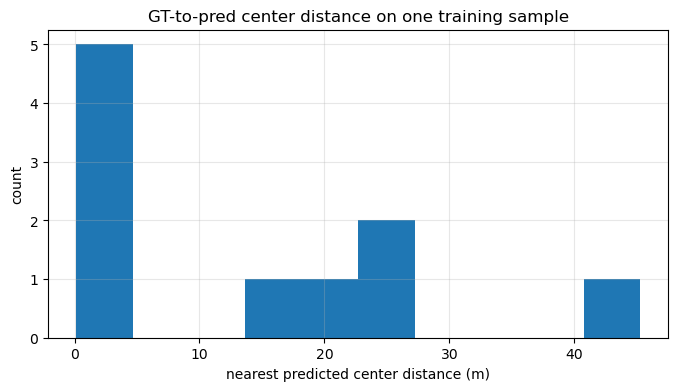

In [21]:
import matplotlib.pyplot as plt

def summarize_sample_fit(model, dataset, sample_index=0, device=device, score_threshold=0.005, max_boxes=50):
    sample = dataset[sample_index]
    pred_boxes, pred_scores, pred_labels = predict_single_sample(
        model,
        sample,
        device=device,
        score_threshold=score_threshold,
        max_boxes=max_boxes,
    )
    gt_boxes = sample.get('gt_boxes_lidar', sample['gt_boxes_ego']).cpu()
    gt_labels = sample['gt_labels'].cpu()

    print(f"sample_token: {sample['img_metas']['sample_token']}")
    print(f"num_gt={gt_boxes.shape[0]}, num_pred={pred_boxes.shape[0]}")

    gt_names = [NUSCENES_CLASSES[int(label)] for label in gt_labels.tolist()]
    pred_names = [NUSCENES_CLASSES[int(label)] for label in pred_labels.tolist()]
    print('\nGT classes:')
    print(gt_names)
    print('\nTop predicted classes:')
    print([(pred_names[i], round(float(pred_scores[i]), 4)) for i in range(len(pred_names))])

    if gt_boxes.numel() == 0 or pred_boxes.numel() == 0:
        print('\nCannot compute matching summary because GT or predictions are empty.')
        return

    gt_centers = gt_boxes[:, :3]
    pred_centers = pred_boxes[:, :3]
    center_dist = torch.cdist(gt_centers, pred_centers, p=2)
    best_dist, best_pred_idx = center_dist.min(dim=1)

    print('\nNearest prediction for each GT:')
    matched_class_count = 0
    for gt_idx in range(gt_boxes.shape[0]):
        pred_idx = int(best_pred_idx[gt_idx])
        gt_name = NUSCENES_CLASSES[int(gt_labels[gt_idx])]
        pred_name = NUSCENES_CLASSES[int(pred_labels[pred_idx])]
        class_match = int(gt_labels[gt_idx]) == int(pred_labels[pred_idx])
        matched_class_count += int(class_match)
        print(
            f"GT {gt_idx:02d}: class={gt_name:<22} | "
            f"pred={pred_idx:02d} ({pred_name:<22}) | "
            f"score={float(pred_scores[pred_idx]):.4f} | "
            f"center_dist={float(best_dist[gt_idx]):.3f} m | "
            f"class_match={class_match}"
        )
        print(
            f"         gt_wlh=({float(gt_boxes[gt_idx, 3]):.2f}, {float(gt_boxes[gt_idx, 4]):.2f}, {float(gt_boxes[gt_idx, 5]):.2f}) | "
            f"pred_wlh=({float(pred_boxes[pred_idx, 3]):.2f}, {float(pred_boxes[pred_idx, 4]):.2f}, {float(pred_boxes[pred_idx, 5]):.2f})"
        )

    print('\nAggregate summary:')
    print(f"mean nearest-center distance: {float(best_dist.mean()):.3f} m")
    print(f"median nearest-center distance: {float(best_dist.median()):.3f} m")
    print(f"class matches among nearest preds: {matched_class_count}/{gt_boxes.shape[0]}")

    plt.figure(figsize=(8, 4))
    plt.hist(best_dist.tolist(), bins=min(10, gt_boxes.shape[0]))
    plt.xlabel('nearest predicted center distance (m)')
    plt.ylabel('count')
    plt.title('GT-to-pred center distance on one training sample')
    plt.grid(True, alpha=0.3)
    plt.show()


summarize_sample_fit(
    model,
    tiny_dataset,
    sample_index=0,
    device=device,
    score_threshold=0.005,
    max_boxes=50,
)


## 17. BEV And Query Diagnostics

This cell visualizes GT and predicted boxes in LiDAR-frame bird's-eye view and reports whether many GT boxes collapse onto the same predicted query.


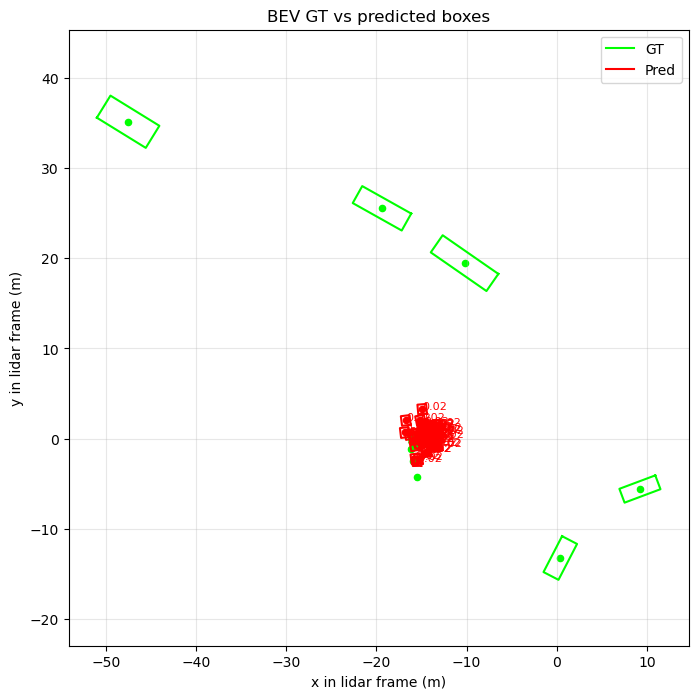

GT-to-query assignment counts:
pred=04 class=truck              score=0.0156 used_by_gt=2 center=(-14.92, 3.27, -0.93) size=(0.97, 1.08, 1.05) yaw=-1.48
pred=07 class=traffic_cone       score=0.0155 used_by_gt=1 center=(-15.51, -2.51, -0.88) size=(0.94, 1.01, 0.98) yaw=-1.55
pred=10 class=truck              score=0.0155 used_by_gt=2 center=(-13.26, -0.87, -0.83) size=(0.94, 1.04, 1.05) yaw=-1.34
pred=15 class=truck              score=0.0155 used_by_gt=1 center=(-16.74, 2.02, -0.96) size=(0.97, 1.07, 1.05) yaw=-1.45
pred=16 class=truck              score=0.0154 used_by_gt=2 center=(-15.76, -0.79, -0.84) size=(0.94, 1.04, 1.02) yaw=-1.38
pred=18 class=truck              score=0.0154 used_by_gt=1 center=(-15.77, -0.05, -0.89) size=(1.01, 1.11, 1.02) yaw=-1.36
pred=27 class=traffic_cone       score=0.0153 used_by_gt=1 center=(-15.66, -2.22, -0.85) size=(0.97, 1.09, 1.02) yaw=-1.43

GT vs nearest predicted box:
GT 00 traffic_cone       -> pred 16 truck              dist=0.697 m | gt_center=

In [22]:
import matplotlib.pyplot as plt

def box_to_bev_corners(boxes):
    if boxes.numel() == 0:
        return boxes.new_zeros((0, 4, 2))
    boxes7 = boxes[..., :7]
    x, y, _, w, l, _, yaw = boxes7.unbind(dim=-1)
    template = boxes7.new_tensor([
        [0.5, 0.5],
        [0.5, -0.5],
        [-0.5, -0.5],
        [-0.5, 0.5],
    ])
    corners = template.unsqueeze(0).repeat(boxes7.shape[0], 1, 1)
    corners[..., 0] *= l[:, None]
    corners[..., 1] *= w[:, None]
    cos_yaw = torch.cos(yaw)
    sin_yaw = torch.sin(yaw)
    rotation = torch.stack([
        torch.stack([cos_yaw, -sin_yaw], dim=-1),
        torch.stack([sin_yaw, cos_yaw], dim=-1),
    ], dim=-2)
    corners = torch.matmul(corners, rotation.transpose(-1, -2))
    centers = torch.stack([x, y], dim=-1)[:, None, :]
    return corners + centers


def draw_bev_boxes(ax, boxes, color, label, scores=None):
    if boxes.numel() == 0:
        return
    corners = box_to_bev_corners(boxes)
    for idx in range(corners.shape[0]):
        pts = corners[idx]
        closed = torch.cat([pts, pts[:1]], dim=0)
        xs = [float(v) for v in closed[:, 0]]
        ys = [float(v) for v in closed[:, 1]]
        ax.plot(xs, ys, color=color, linewidth=1.5, label=label if idx == 0 else None)
        center_x = float(boxes[idx, 0])
        center_y = float(boxes[idx, 1])
        ax.scatter([center_x], [center_y], c=color, s=20)
        if scores is not None:
            ax.text(center_x, center_y, f'{float(scores[idx]):.2f}', color=color, fontsize=8)


def analyze_query_collapse(model, dataset, sample_index=0, device=device, score_threshold=0.005, max_boxes=50):
    sample = dataset[sample_index]
    pred_boxes, pred_scores, pred_labels = predict_single_sample(
        model,
        sample,
        device=device,
        score_threshold=score_threshold,
        max_boxes=max_boxes,
    )
    gt_boxes = sample.get('gt_boxes_lidar', sample['gt_boxes_ego']).cpu()
    gt_labels = sample['gt_labels'].cpu()

    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    draw_bev_boxes(ax, gt_boxes, color='lime', label='GT')
    draw_bev_boxes(ax, pred_boxes, color='red', label='Pred', scores=pred_scores)
    ax.set_xlabel('x in lidar frame (m)')
    ax.set_ylabel('y in lidar frame (m)')
    ax.set_title('BEV GT vs predicted boxes')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.legend()
    plt.show()

    if gt_boxes.numel() == 0 or pred_boxes.numel() == 0:
        print('Cannot analyze query collapse because GT or predictions are empty.')
        return

    gt_centers = gt_boxes[:, :3]
    pred_centers = pred_boxes[:, :3]
    center_dist = torch.cdist(gt_centers, pred_centers, p=2)
    best_dist, best_pred_idx = center_dist.min(dim=1)

    unique_pred_ids, counts = torch.unique(best_pred_idx, return_counts=True)
    print('GT-to-query assignment counts:')
    for pred_idx, count in zip(unique_pred_ids.tolist(), counts.tolist()):
        pred_name = NUSCENES_CLASSES[int(pred_labels[pred_idx])]
        pred_box = pred_boxes[pred_idx]
        print(
            f"pred={pred_idx:02d} class={pred_name:<18} score={float(pred_scores[pred_idx]):.4f} "
            f"used_by_gt={count} center=({float(pred_box[0]):.2f}, {float(pred_box[1]):.2f}, {float(pred_box[2]):.2f}) "
            f"size=({float(pred_box[3]):.2f}, {float(pred_box[4]):.2f}, {float(pred_box[5]):.2f}) yaw={float(pred_box[6]):.2f}"
        )

    print('\nGT vs nearest predicted box:')
    for gt_idx in range(gt_boxes.shape[0]):
        pred_idx = int(best_pred_idx[gt_idx])
        gt_box = gt_boxes[gt_idx]
        pred_box = pred_boxes[pred_idx]
        gt_name = NUSCENES_CLASSES[int(gt_labels[gt_idx])]
        pred_name = NUSCENES_CLASSES[int(pred_labels[pred_idx])]
        print(
            f"GT {gt_idx:02d} {gt_name:<18} -> pred {pred_idx:02d} {pred_name:<18} "
            f"dist={float(best_dist[gt_idx]):.3f} m | "
            f"gt_center=({float(gt_box[0]):.2f}, {float(gt_box[1]):.2f}, {float(gt_box[2]):.2f}) | "
            f"pred_center=({float(pred_box[0]):.2f}, {float(pred_box[1]):.2f}, {float(pred_box[2]):.2f})"
        )


analyze_query_collapse(
    model,
    tiny_dataset,
    sample_index=0,
    device=device,
    score_threshold=0.005,
    max_boxes=50,
)
